# 📡 Telecom Incident Intelligence Platform

## Project Overview

Telecommunication networks rely on complex infrastructure where equipment failures can lead to service disruptions, customer dissatisfaction, and revenue loss. Understanding these failures and improving response strategies is critical for maintaining network reliability.

This project analyzes telecom equipment failure data to uncover patterns in failures, evaluate recovery performance, and assess their impact on customers. Beyond analysis, the project also focuses on identifying high-risk components and proposing strategies to prevent future incidents.

---

## Objectives

The main objectives of this analysis are:

* To analyze failure patterns across different equipment types, locations, and failure categories
* To evaluate recovery efficiency using metrics such as Mean Time to Recovery (MTTR) and success rates
* To identify high-impact failures that significantly affect customers
* To detect high-risk equipment and regions prone to repeated failures
* To propose data-driven strategies for improving reliability and preventing future failures

---

## Key Questions

This project aims to answer the following:

* What types of failures occur most frequently?
* Which equipment and regions are most prone to failures?
* How efficient is the recovery process?
* Which failures have the greatest impact on customers?
* What patterns can help predict or prevent future failures?

---

## Approach

The analysis follows a structured pipeline:

1. Data cleaning and preprocessing
2. Feature engineering for time-based and impact analysis
3. Exploratory data analysis (EDA) to uncover trends and patterns
4. Failure and recovery performance analysis
5. Risk identification and prevention insights

---

## Expected Outcome

The final outcome of this project is an analytical framework and interactive dashboard that enables:

* Monitoring of telecom failures and recovery performance
* Identification of high-risk equipment and regions
* Insight-driven decision-making for preventive maintenance
* Improved operational efficiency and reduced downtime

---

## Deployment

To make the insights actionable, this analysis will be deployed as an interactive dashboard using Streamlit, allowing users to explore failures, monitor key metrics, and identify risks in real time.


**1. Data Cleaning and Preprocessing**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
#matplotlib inline

In [2]:
df = pd.read_csv('telecommunications-equipment-failure-logs.csv')

In [4]:
df.head()

,failure_id,provider_id,equipment_id,equipment_type,location_site,location_city,location_state,location_country,failure_datetime,failure_type,...,failure_description,detected_by,recovery_action,recovery_start_datetime,recovery_end_datetime,recovery_duration_minutes,recovery_successful,recovery_notes,reported_by,affected_customers_count
0,F10001,TCom-01,RT-0601A,router,SiteA-CHI-01,Chicago,IL,USA,2024-04-03T09:17:00Z,hardware,...,"Core router failed due to overheating, network...",automated monitoring,Replaced faulty cooling unit and restarted cor...,2024-04-03T09:25:00Z,2024-04-03T10:35:00Z,70,True,"Replacement successful, all systems operational.",sys_admin_23,950
1,F10002,NetWave,SW-7812Q,switch,SwitchRoom-TYO-03,Tokyo,Tokyo,Japan,2024-03-18T18:46:00Z,network,...,"Switch lost connectivity to upstream router, p...",automated monitoring,"Restored uplink port, verified routing tables.",2024-03-18T18:47:00Z,2024-03-18T19:10:00Z,23,True,"Connectivity restored, monitoring for further ...",net_ops_tyo,480
2,F10003,GlobeTel,BS-9001Z,base_station,RuralStation-NBO-04,Nairobi,Nairobi County,Kenya,2024-05-09T12:06:00Z,environmental,...,Base station down due to heavy rain and flooding.,manual inspection,"Elevated equipment, replaced damaged power sup...",2024-05-09T13:11:00Z,2024-05-09T18:45:00Z,334,True,"All repairs completed, base station back online.",field_ops_nbo,4200
3,F10004,TCom-02,XCVR-312B,transceiver,LabCenter-SYD-02,Sydney,NSW,Australia,2024-03-21T11:20:00Z,hardware,...,Transceiver module failed during peak traffic.,automated monitoring,"Module swapped, recalibrated optical lines.",2024-03-21T11:27:00Z,2024-03-21T12:03:00Z,36,True,No further errors detected post-replacement.,sys_admin_aus,320
4,F10005,GlobeTel,FOC-0112F,fiber_optic_cable,TunnelFOC-REY-10,Reykjavik,Capital Region,Iceland,2024-04-13T03:50:00Z,environmental,...,Undersea fiber optic cable damaged by seismic ...,manual inspection,"Cable segment replaced, rerouted traffic durin...",2024-04-13T06:00:00Z,2024-04-13T18:20:00Z,740,False,Temporary fix in place; full replacement sched...,marine_ops_ic,15200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   failure_id                 200 non-null    object
 1   provider_id                200 non-null    object
 2   equipment_id               200 non-null    object
 3   equipment_type             200 non-null    object
 4   location_site              200 non-null    object
 5   location_city              200 non-null    object
 6   location_state             200 non-null    object
 7   location_country           200 non-null    object
 8   failure_datetime           200 non-null    object
 9   failure_type               200 non-null    object
 10  failure_severity           200 non-null    object
 11  failure_description        200 non-null    object
 12  detected_by                200 non-null    object
 13  recovery_action            200 non-null    object
 14  recovery_s

In [6]:
df.isna().values.any()

np.False_

In [7]:
df.duplicated().values.any()    

np.False_

In [8]:
df.describe()

,recovery_duration_minutes,affected_customers_count
count,200.000000,200.00000
mean,149.705000,3559.93000
std,237.467052,6679.00936
min,0.000000,0.00000
25%,20.000000,117.50000
50%,45.000000,535.00000
75%,185.000000,2325.00000
max,1785.000000,33000.00000


**Partial Conclusion**

We can deduce the following from the above results:
- 50% of failures are resolved in under 45 minutes.
- A few massive outages (up to 30 hours) are skewing the average upward, making "typical" performance look worse than it is.
- Most incidents are small, but major outliers affect up to 33,000 customers, creating high volatility.
- The "0" values suggest the dataset includes false alarms or tests that didn't actually cause downtime.


**2. Time-based and impact analysis**

We observe that the Dates are currently stored as text, which prevents us from seeing time-based trends.

In [9]:
df['failure_datetime'] = pd.to_datetime(df['failure_datetime'], format='mixed', utc=True)
df['recovery_start_datetime'] = pd.to_datetime(df['recovery_start_datetime'], format='mixed', utc=True)
df['recovery_end_datetime'] = pd.to_datetime(df['recovery_end_datetime'], format='mixed', utc=True)
df['failure_duration'] = (df['recovery_end_datetime'] - df['failure_datetime']).dt.total_seconds() / 3600.0

**3. EDA**

**What types of failures occur most frequently**

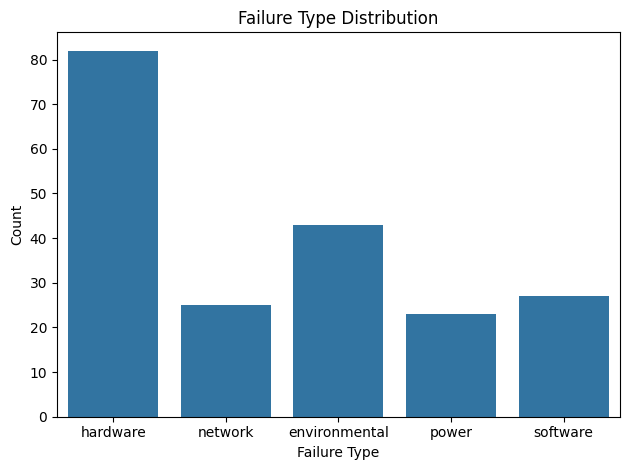

In [10]:
# Failure Type Distribution
sns.countplot(x='failure_type', data=df)
plt.title('Failure Type Distribution')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

From the above, the type of failure types that occur frequently are mostly hardware failures, followed by environmental failure types etc.

Text(0.5, 1.0, 'Equipment Types Distribution')

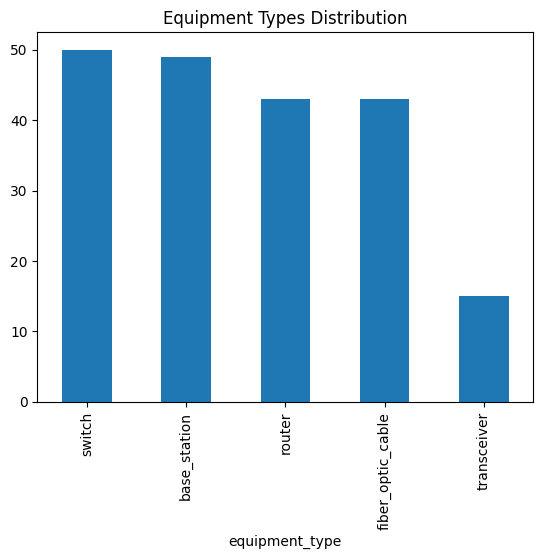

In [11]:
df['equipment_type'].value_counts().plot(kind='bar')
plt.title('Equipment Types Distribution')

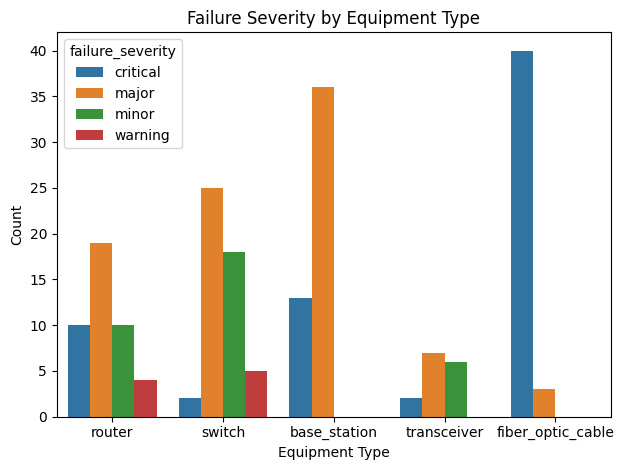

In [12]:
plt.figure_size=(12, 6)
sns.countplot(x='equipment_type', data=df, hue='failure_severity')
plt.title('Failure Severity by Equipment Type')
plt.xlabel('Equipment Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Top 10 Sites with Most Failures')

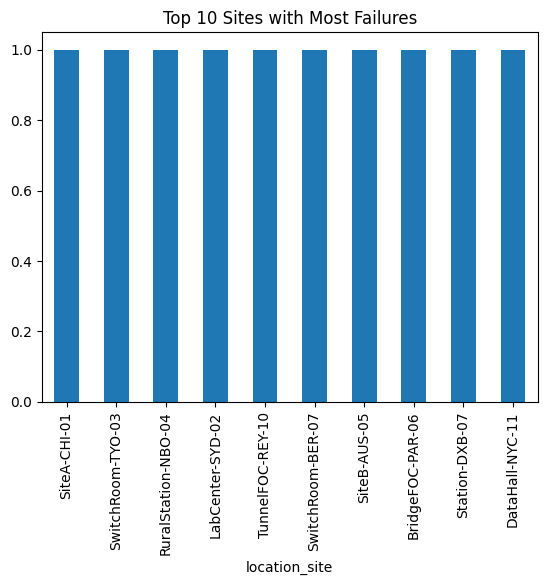

In [13]:
df['location_site'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Sites with Most Failures')

Text(0.5, 1.0, 'Top 10 Cities with Most Failures')

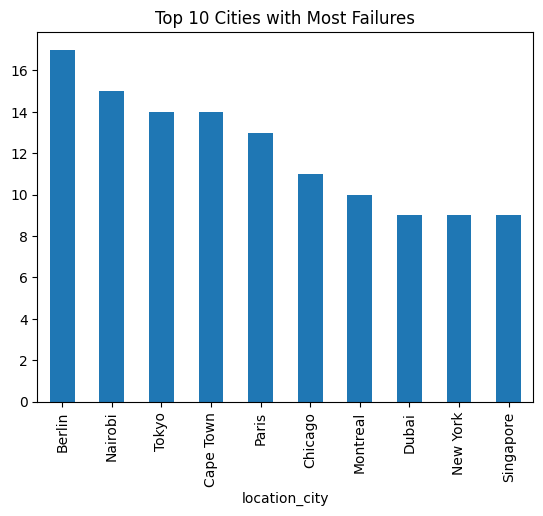

In [14]:
df['location_city'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Cities with Most Failures')

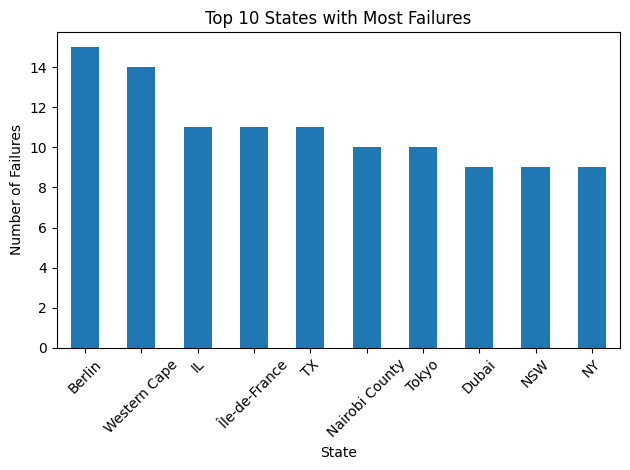

In [15]:
df['location_state'].value_counts().head(10).plot(kind='bar')   
plt.title('Top 10 States with Most Failures')
plt.xlabel('State')     
plt.ylabel('Number of Failures')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

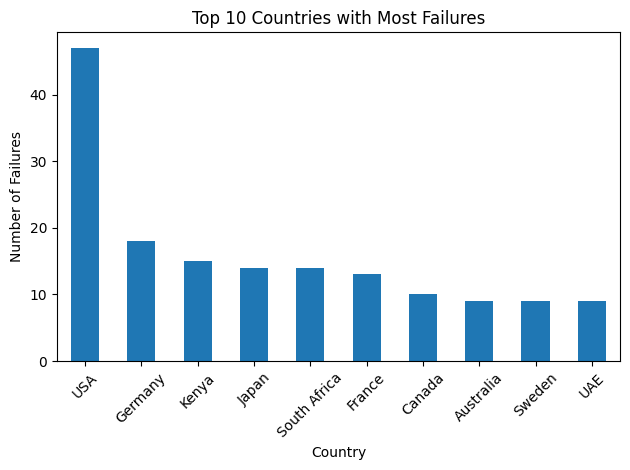

In [16]:
df['location_country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries with Most Failures')
plt.xlabel('Country')
plt.ylabel('Number of Failures')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Time Analysis**

In [17]:
df['month']=df['failure_datetime'].dt.month
df['day_of_week']=df['failure_datetime'].dt.dayofweek
df['hour'] = df['failure_datetime'].dt.hour  

In [18]:
mttr=df.groupby('equipment_type')['failure_duration'].mean().sort_values(ascending=False)
print(mttr)

equipment_type
fiber_optic_cable    8.245736
base_station         3.063946
transceiver          0.701111
router               0.639535
switch               0.410333
Name: failure_duration, dtype: float64


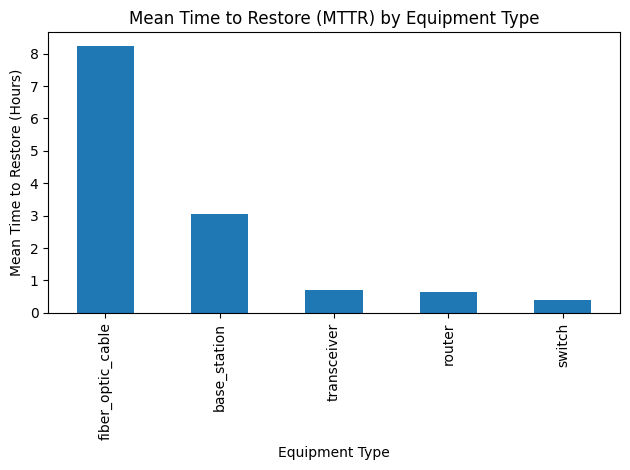

In [19]:
mttr.plot(kind='bar')
plt.title('Mean Time to Restore (MTTR) by Equipment Type')   
plt.xlabel('Equipment Type')
plt.ylabel('Mean Time to Restore (Hours)')
plt.tight_layout()
plt.show()

<Axes: xlabel='day_of_week'>

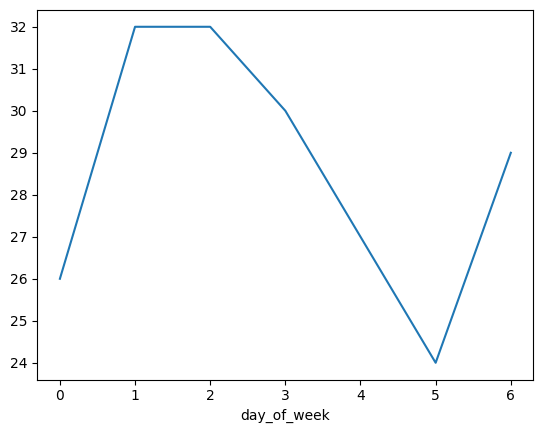

In [20]:
df.groupby('day_of_week').size().plot()

**Customer Impact**

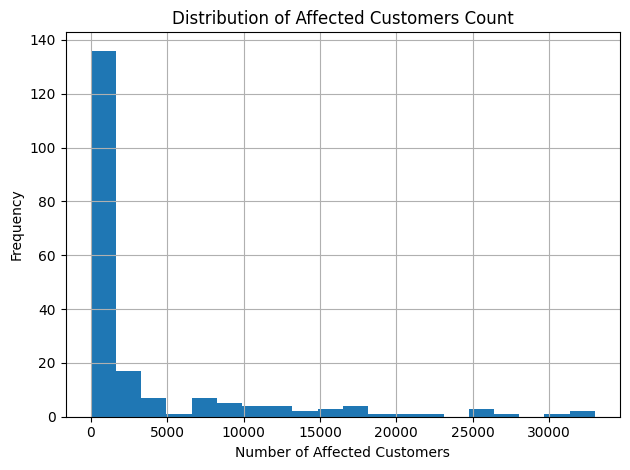

In [21]:
df['affected_customers_count'].hist(bins=20)
plt.title('Distribution of Affected Customers Count')
plt.xlabel('Number of Affected Customers')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [22]:
df.sort_values(by='affected_customers_count', ascending=False).head(5)

,failure_id,provider_id,equipment_id,equipment_type,location_site,location_city,location_state,location_country,failure_datetime,failure_type,...,recovery_end_datetime,recovery_duration_minutes,recovery_successful,recovery_notes,reported_by,affected_customers_count,failure_duration,month,day_of_week,hour
11,F10012,GlobeTel,FOC-0121X,fiber_optic_cable,UnderseaFOC-CPT-02,Cape Town,Western Cape,South Africa,2024-05-03 04:01:00+00:00,environmental,...,2024-05-03 20:55:00+00:00,895,False,"Major outages remain, permanent repairs underway.",marine_ops_cpt,33000,16.900000,5,4,4
173,F6034,NetWave,FOC-3211S,fiber_optic_cable,UnderseaPAR-1,Paris,Île-de-France,France,2024-04-01 07:21:00+00:00,environmental,...,2024-04-01 18:15:00+00:00,630,False,"Repairs ongoing, damage assessment underway.",field_ops_paris,32000,10.900000,4,0,7
99,F3010,GlobeTel,FOC-2217V,fiber_optic_cable,UnderseaFiber-CPT01,Cape Town,Western Cape,South Africa,2023-04-15 02:10:00+00:00,environmental,...,2023-04-15 09:40:00+00:00,400,False,Partial restoration; additional repairs schedu...,marine_team_cpt01,30000,7.500000,4,5,2
122,F3033,NetWave,FOC-5072W,fiber_optic_cable,UnderseaFiber-ST02,Stockholm,Stockholm County,Sweden,2023-04-20 03:10:00+00:00,environmental,...,2023-04-20 10:00:00+00:00,380,False,"Seismic repairs ongoing, full restoration expe...",marine_team_st02,28000,6.833333,4,3,3
131,F3042,NetWave,FOC-3911P,fiber_optic_cable,UnderseaFiber-TK04,Tokyo,Tokyo Prefecture,Japan,2023-04-26 06:20:00+00:00,environmental,...,2023-04-26 16:40:00+00:00,600,False,"Repairs ongoing, full restoration expected in ...",marine_team_tk04,26000,10.333333,4,2,6


In [23]:
df.groupby('failure_type')['affected_customers_count'].mean()

failure_type
environmental    10304.232558
hardware          2784.182927
network            224.280000
power             1514.130435
software             6.259259
Name: affected_customers_count, dtype: float64

## Feature Engineering

In [25]:
cats_feats = df.select_dtypes(include=['object']).columns

In [26]:
cats_feats

Index(['failure_id', 'provider_id', 'equipment_id', 'equipment_type',
       'location_site', 'location_city', 'location_state', 'location_country',
       'failure_type', 'failure_severity', 'failure_description',
       'detected_by', 'recovery_action', 'recovery_notes', 'reported_by'],
      dtype='object')

In [27]:
# Number of unqiue features in each categorical column
for col in cats_feats:
    print(f"{col}: {df[col].nunique()}")

failure_id: 200
provider_id: 4
equipment_id: 200
equipment_type: 5
location_site: 200
location_city: 27
location_state: 41
location_country: 16
failure_type: 5
failure_severity: 4
failure_description: 200
detected_by: 2
recovery_action: 199
recovery_notes: 198
reported_by: 179


In [28]:
df_final = df.copy()

In [29]:
df_final['reported_by'].head(20)

0       sys_admin_23
1        net_ops_tyo
2      field_ops_nbo
3      sys_admin_aus
4      marine_ops_ic
5      field_ops_ber
6       sys_admin_tx
7     fiber_team_par
8      field_ops_dxb
9       sys_admin_ny
10       net_ops_ber
11    marine_ops_cpt
12       qa_team_del
13     sys_admin_sea
14    fiber_team_ber
15     field_ops_cpt
16       lab_ops_mtl
17    marine_ops_sin
18     field_ops_nbo
19        qa_team_sf
Name: reported_by, dtype: object

In [30]:
df_final[['reporter_dept', 'reporter_loc']] = df_final['reported_by'].str.rsplit('_', n=1, expand=True)
print(df_final['reporter_dept'].nunique()) 


16


In [31]:
df_final = df_final.drop(columns=['reporter_loc', 'reported_by'])

In [32]:
df_final['recovery_action'].head(20)

0     Replaced faulty cooling unit and restarted cor...
1        Restored uplink port, verified routing tables.
2     Elevated equipment, replaced damaged power sup...
3           Module swapped, recalibrated optical lines.
4     Cable segment replaced, rerouted traffic durin...
5      UPS installed, checked for further power issues.
6     Rolled back update, reinstalled previous firmw...
7                 Spliced cable, tested link integrity.
8           Generator repaired, base station restarted.
9      Power supply swapped, verified link restoration.
10    Reconfigured routing protocol, cleared ARP cache.
11    Cable section replaced, rerouted international...
12             Reset interface, applied firmware patch.
13       Restarted logging service, checked error logs.
14               Cable spliced, tested for signal loss.
15      Transformer replaced, base station reactivated.
16              Disabled affected port, replaced cable.
17          Cable rerouted, full replacement sch

From our recovery action feature, we observe that there some repetitive actions that can be extracted and hence beneficial for our model

In [33]:
# Create new binary features based on keywords
df_final['act_replaced'] = df_final['recovery_action'].str.contains('replace|swap|spliced', case=False).astype(int)
df_final['act_restarted'] = df_final['recovery_action'].str.contains('restart|reboot|reactivate|reset', case=False).astype(int)
df_final['act_firmware'] = df_final['recovery_action'].str.contains('firmware|update|patch|rollback', case=False).astype(int)
df_final['act_rerouted'] = df_final['recovery_action'].str.contains('reroute|traffic', case=False).astype(int)

# Extracting what was fixed as well
df['comp_cable'] = df['recovery_action'].str.contains('cable', case=False).astype(int)
df['comp_power'] = df['recovery_action'].str.contains('power|ups|generator|battery', case=False).astype(int)



In [34]:
df_final=df_final.drop(columns=['recovery_action'])

In [35]:
df_final = df_final.drop(columns=['recovery_notes'])

In [36]:
df_final['failure_description'].head(20)

0     Core router failed due to overheating, network...
1     Switch lost connectivity to upstream router, p...
2     Base station down due to heavy rain and flooding.
3        Transceiver module failed during peak traffic.
4     Undersea fiber optic cable damaged by seismic ...
5      Switch rebooted unexpectedly after voltage drop.
6     Router firmware crashed during configuration u...
7     Fiber cable break detected under bridge crossing.
8         Base station outage due to generator failure.
9     Switch power supply failed, downstream links o...
10    Major packet loss at core router, affecting al...
11      Undersea cable hit by anchor, severe data loss.
12    Router interface froze during internal QA test...
13    Switch logging error detected, no impact to tr...
14            Tunnel fiber cable severed by excavation.
15    Base station lost power after transformer expl...
16    Switch port flapping, noticed during lab simul...
17    Undersea cable damage due to marine constr

We could build a 'cause' profile for each failure

In [37]:
# Create flags for the root cause
df_final['cause_env'] = df_final['failure_description'].str.contains('rain|flood|seismic|marine|weather', case=False).astype(int)
df_final['cause_power'] = df_final['failure_description'].str.contains('voltage|power|generator|battery|transformer', case=False).astype(int)
df_final['cause_hardware'] = df_final['failure_description'].str.contains('failed|damaged|severed|break|hit', case=False).astype(int)
df_final['cause_software'] = df_final['failure_description'].str.contains('firmware|software|update|patch|rollback', case=False).astype(int)
df_final['cause_network'] = df_final['failure_description'].str.contains('network|congestion|traffic|routing', case=False).astype(int)

In [38]:
df_final = df_final.drop(columns=['failure_description'])

In [39]:
df_final['location_site'].head(20)

0             SiteA-CHI-01
1        SwitchRoom-TYO-03
2      RuralStation-NBO-04
3         LabCenter-SYD-02
4         TunnelFOC-REY-10
5        SwitchRoom-BER-07
6             SiteB-AUS-05
7         BridgeFOC-PAR-06
8           Station-DXB-07
9          DataHall-NYC-11
10         CoreRoom-BER-09
11      UnderseaFOC-CPT-02
12        LabCenter-DEL-03
13         DataHall-SEA-10
14        TunnelFOC-BER-08
15    RemoteStation-CPT-09
16        LabSwitch-MTL-14
17      UnderseaFOC-SIN-06
18    RemoteStation-NBO-11
19           TestLab-SF-04
Name: location_site, dtype: object

We observe that the location site feature follows a strict naming convertion:[FacilityType]-[CityCode]-[Rack/ID].

In [40]:
# Splitting the location site feature into three parts
df_final[['site_type', 'site_city_code', 'site_id']] = df_final['location_site'].str.split('-', expand=True)

In [41]:
df_final.drop(columns=['location_site','site_city_code','site_id'], inplace=True)

In [42]:
df_final['equipment_id'].head(20)

0      RT-0601A
1      SW-7812Q
2      BS-9001Z
3     XCVR-312B
4     FOC-0112F
5      SW-1847L
6      RT-0602B
7     FOC-0041C
8      BS-9002A
9      SW-5691M
10     RT-0701D
11    FOC-0121X
12     RT-0603C
13     SW-5692J
14    FOC-0156E
15     BS-9003B
16     SW-5693F
17    FOC-0189P
18     BS-9004L
19     RT-0604K
Name: equipment_id, dtype: object

Here the equipment ID is nothing just but a coded summary of the hardware. Just like the location sites, these IDs follow a clear pattern: [DeviceType]-[Model/SerialNumber][Version/Batch]. Given that we already have a feature that lists the different device types, the prefixes of our equipment ID will therefore just be redundant.

Furthermore, the failure id feature does not really help much in training our model, so I went forth to drop it as well

In [43]:
df_final.drop(columns=['failure_id','equipment_id'], inplace=True)

In [44]:
datetimes=df_final.select_dtypes(include=['datetime64[ns, UTC]']).columns
datetimes

Index(['failure_datetime', 'recovery_start_datetime', 'recovery_end_datetime'], dtype='object')

In [45]:
# 1. Response Time: How long did it take to start fixing it after it failed?
df_final['response_delay_mins'] = (df_final['recovery_start_datetime'] - df_final['failure_datetime']).dt.total_seconds() / 60

# 2. Repair Duration: How long did the actual repair work take?
df_final['repair_work_mins'] = (df_final['recovery_end_datetime'] - df_final['recovery_start_datetime']).dt.total_seconds() / 60

Earlier in our analysis, we got the month, hour and dayofweek columns from our failure_datetime column and equally obtained the failure duration feature which corresponds to the total downtime in hours.
I went ahead to drop the recovery_start_datetime and recovery_end_datetime feature so as not overfit our model.

In [46]:
df_final.drop(columns=['failure_datetime','recovery_start_datetime','recovery_end_datetime'], inplace=True)

In [47]:
# Target Variable Failure Severity
mapping = {'critical': 3, 'major': 2, 'minor': 1, 'warning': 0}
df_final['failure_severity'] = df_final['failure_severity'].map(mapping)

In [48]:
df_final.select_dtypes(include=['object']).columns

Index(['provider_id', 'equipment_type', 'location_city', 'location_state',
       'location_country', 'failure_type', 'detected_by', 'reporter_dept',
       'site_type'],
      dtype='object')

In [49]:
unique={}
for col in df_final.select_dtypes(include=['object']).columns:
    unique[col] = df_final[col].nunique()
unique

{'provider_id': 4,
 'equipment_type': 5,
 'location_city': 27,
 'location_state': 41,
 'location_country': 16,
 'failure_type': 5,
 'detected_by': 2,
 'reporter_dept': 16,
 'site_type': 74}

## Model Selection and Evaluation

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore') 

In [51]:
X = df_final.drop(columns=['failure_severity'])
y = df_final['failure_severity']

In [ ]:
categorical_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [53]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=101))
])

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=101,stratify=y)

In [55]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [56]:
y_pred = pipeline.predict(X_test)

In [57]:
print(classification_report(y_test, y_pred))
print('\n')
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.91      1.00      0.95        10
           2       0.96      0.96      0.96        27
           3       0.95      0.95      0.95        20

    accuracy                           0.95        60
   macro avg       0.96      0.89      0.92        60
weighted avg       0.95      0.95      0.95        60



[[ 2  1  0  0]
 [ 0 10  0  0]
 [ 0  0 26  1]
 [ 0  0  1 19]]


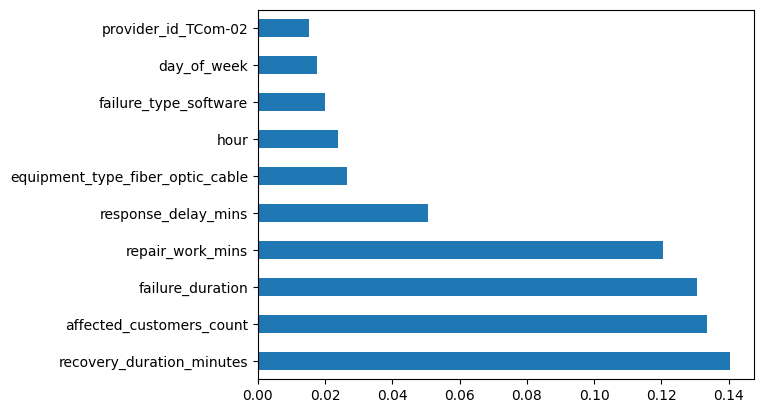

In [58]:
ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
feature_names = list(ohe.get_feature_names_out(categorical_features)) + [
    col for col in X.columns if col not in categorical_features
]
feat_importances = pd.Series(
    pipeline.named_steps['classifier'].feature_importances_,
    index=feature_names
)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()


The "Heavy Hitters" (Downtime & Duration)

The features failure_duration, repair_work_mins, and recovery_duration_minutes are essentially all the same thing as they measure how long the problem lasted.
The Leakage Risk: Given we are trying to predict Failure Severity (0-4) at the moment the failure starts, we wouldn't know the "repair work duration" yet because the repair hasn't finished. By leaving these features, we are essentially "cheating" by telling the model the outcome.

So, I went on to drop these features and test the performance of the model on test data.

In [59]:
df1 = df_final.copy()

In [60]:
df1.drop(columns=['failure_duration','repair_work_mins','recovery_duration_minutes','response_delay_mins'], inplace=True)

In [61]:
X=df1.drop(columns=['failure_severity'])
y=df1['failure_severity']

In [62]:
cat_features = X.select_dtypes(include=['object']).columns
# Create a column transformer for one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ],
    remainder='passthrough'
)

In [63]:
pipeline_rfc = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(max_depth =6,class_weight='balanced',random_state=101,))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [65]:
pipeline_rfc.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [66]:
predictions1 = pipeline_rfc.predict(X_test)

In [67]:
print(classification_report(y_test, predictions1))
print("\n")
print(confusion_matrix(y_test, predictions1))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.86      0.86      0.86        14
           2       0.79      0.90      0.84        29
           3       0.82      0.64      0.72        14

    accuracy                           0.82        60
   macro avg       0.87      0.77      0.80        60
weighted avg       0.82      0.82      0.81        60



[[ 2  1  0  0]
 [ 0 12  2  0]
 [ 0  1 26  2]
 [ 0  0  5  9]]


While the 95% model looks better, it requires us to know the future (recovery time) to work. The 82% model can predict the severity the moment the failure occurs, allowing us to triage resources instantly.

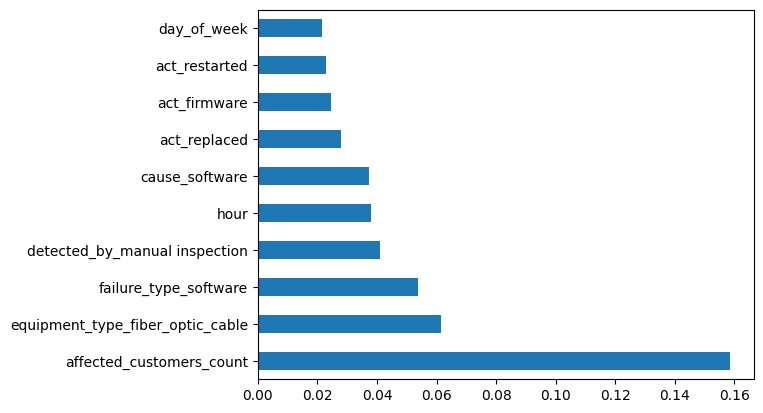

In [68]:
ohe = pipeline_rfc.named_steps['preprocessor'].named_transformers_['cat']
feature_names = list(ohe.get_feature_names_out(categorical_features)) + [
    col for col in X.columns if col not in categorical_features
]
feat_importances = pd.Series(
    pipeline_rfc.named_steps['classifier'].feature_importances_,
    index=feature_names
)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()


**SVM**

In [69]:
param_grid = {'svm__C': [0.1, 1, 10, 100], 'svm__gamma': [1, 0.1, 0.01, 0.001]}

pipeline_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)),
    ('svm', SVC(kernel='rbf', class_weight='balanced'))
])

grid = GridSearchCV(pipeline_svm, param_grid=param_grid, refit=True, verbose=2)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ...........................svm__C=0.1, svm__gamma=1; total time=   0.0s
[CV] END ...........................svm__C=0.1, svm__gamma=1; total time=   0.0s
[CV] END ...........................svm__C=0.1, svm__gamma=1; total time=   0.0s
[CV] END ...........................svm__C=0.1, svm__gamma=1; total time=   0.0s
[CV] END ...........................svm__C=0.1, svm__gamma=1; total time=   0.0s
[CV] END .........................svm__C=0.1, svm__gamma=0.1; total time=   0.0s
[CV] END .........................svm__C=0.1, svm__gamma=0.1; total time=   0.0s
[CV] END .........................svm__C=0.1, svm__gamma=0.1; total time=   0.0s
[CV] END .........................svm__C=0.1, svm__gamma=0.1; total time=   0.0s
[CV] END .........................svm__C=0.1, svm__gamma=0.1; total time=   0.0s
[CV] END ........................svm__C=0.1, svm__gamma=0.01; total time=   0.0s
[CV] END ........................svm__C=0.1, svm

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1, ...], 'svm__gamma': [1, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 

In [70]:
grid.best_params_

{'svm__C': 1, 'svm__gamma': 0.001}

In [71]:
grid = GridSearchCV(pipeline_svm, param_grid={'svm__C': [1], 'svm__gamma': [0.001]}, refit=True, verbose=2)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END .........................svm__C=1, svm__gamma=0.001; total time=   0.0s
[CV] END .........................svm__C=1, svm__gamma=0.001; total time=   0.0s
[CV] END .........................svm__C=1, svm__gamma=0.001; total time=   0.0s
[CV] END .........................svm__C=1, svm__gamma=0.001; total time=   0.0s
[CV] END .........................svm__C=1, svm__gamma=0.001; total time=   0.0s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [1], 'svm__gamma': [0.001]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and c

In [72]:
grid_predictions = grid.predict(X_test)

In [73]:
print(classification_report(y_test, grid_predictions))
print('\n')
print(confusion_matrix(y_test, grid_predictions))

              precision    recall  f1-score   support

           0       0.40      0.67      0.50         3
           1       0.79      0.79      0.79        14
           2       0.70      0.79      0.74        29
           3       0.75      0.43      0.55        14

    accuracy                           0.70        60
   macro avg       0.66      0.67      0.64        60
weighted avg       0.72      0.70      0.69        60



[[ 2  0  1  0]
 [ 1 11  2  0]
 [ 1  3 23  2]
 [ 1  0  7  6]]


**Conclusion:**

Our Random Forest Classifier seems to have perform far better than SVC. 

## Saving the Model

In [74]:
import joblib

In [75]:
joblib.dump(pipeline_rfc, 'telecom_failure_rf_model.pkl')

['telecom_failure_rf_model.pkl']

In [ ]:
# LOAD DATA

df = pd.read_csv("telecommunications-equipment-failure-logs.csv")


# TARGET MAPPING

mapping = {'critical': 3, 'major': 2, 'minor': 1, 'warning': 0}
df['failure_severity'] = df['failure_severity'].map(mapping)


# SELECT DEPLOYABLE FEATURES

features = [
    'equipment_type',
    'failure_type',
    'location_country',
    'provider_id',
    'detected_by',
    'affected_customers_count'
]

X = df[features]
y = df['failure_severity']


# PREPROCESSING

categorical = [
    'equipment_type',
    'failure_type',
    'location_country',
    'provider_id',
    'detected_by'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ],
    remainder='passthrough'
)


# PIPELINE

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        class_weight='balanced',
        random_state=101
    ))
])


# TRAIN

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101, stratify=y
)

pipeline.fit(X_train, y_train)


# SAVE MODEL

joblib.dump(pipeline, "telecom_failure_model.pkl")

print("✅ Model saved as telecom_failure_model.pkl")

✅ Model saved as pipeline.pkl
